# 추석에 과일값은 정말 오를까? — 사과·배 소매가격 분석

**질문.** 2026-09-23 이마트 신도림점에서 제수용 과일이 매대 전면을 차지한 걸 봤다.
명절 수요가 몰리면 가격도 오를 것 같은데, 실제 전국 소매가격 데이터로 확인해본다.

**데이터.** 공공데이터포털 「한국농수산식품유통공사_기간별 소매가격 정보 조회」
- 사과(411)·배(412), 2025-08-01 ~ 10-31 / 2026-08-01 ~ 10-05, 10개 단위 소매가격
- 전국 58개 조사처: 전통시장(이름 있는 시장) / 유통업체(익명 처리된 `X-유통`)
- 수집: `fetch_retail.py` (인증키는 `.env`, 저장소에 올리지 않음)

**기준일.** 추석 당일을 D-day로 맞춰 두 해를 비교한다.
2025 추석 = 10월 6일, 2026 추석 = 9월 25일.

In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", "{:,.1f}".format)

CHUSEOK = {2025: pd.Timestamp("2025-10-06"), 2026: pd.Timestamp("2026-09-25")}
files = sorted(Path("data/raw").glob("retail_411-412_*.csv"))
df = pd.concat([pd.read_csv(f, dtype=str) for f in files], ignore_index=True)

df["date"] = pd.to_datetime(df.exmn_ymd)
df["year"] = df.date.dt.year
df["price"] = pd.to_numeric(df.exmn_dd_prc, errors="coerce")   # 10개당 원
df["dday"] = (df.date - df.year.map(CHUSEOK)).dt.days            # 음수 = 추석 전
df["channel"] = np.where(df.mrkt_nm.str.contains("유통"), "유통업체", "전통시장")
df = df.dropna(subset=["price"]).drop_duplicates(["date", "mrkt_cd", "item_cd", "vrty_cd", "grd_cd"])

print(f"{len(df):,}행 · 조사처 {df.mrkt_cd.nunique()}곳")
df.groupby(["year", "item_nm", "vrty_nm", "grd_nm"]).size().unstack("year").fillna(0).astype(int)

18,865행 · 조사처 58곳


year                     2025  2026
item_nm vrty_nm  grd_nm            
배       신고       상품      1704   973
                 중품      1164   740
        원황       상품      1063  1114
                 중품       159   273
사과      쓰가루(아오리) 상품       385   645
                 중품      1003   824
        홍로       상품      1935  1172
                 중품      2129  1323
        후지       상품       579   679
                 중품       402   599

## 1. 단순 평균의 함정

먼저 매주 전국 가격 중앙값을 그대로 그려본다. 그런데 이 값은 **그 주에 조사된 시장 구성**이 바뀌면 같이 흔들린다.
그래서 이후 분석은 **시장별로 자기 기준가 대비 몇 %인지(지수)** 를 먼저 구하고 그걸 모은다.

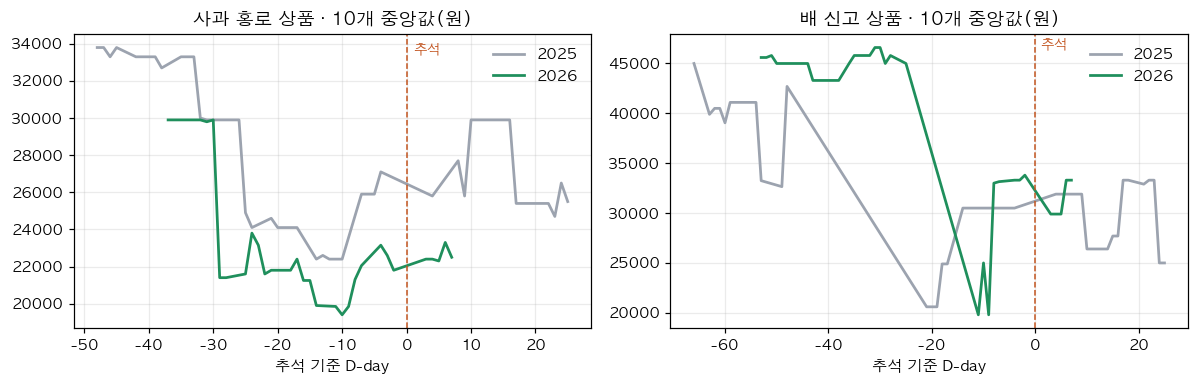

In [2]:
FOCUS = [("사과", "홍로"), ("배", "신고")]   # 추석 대표 제수용 품종
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (item, vrty) in zip(axes, FOCUS):
    for y, c in [(2025, "#9CA3AF"), (2026, "#1F8F5C")]:
        s = df[(df.year == y) & (df.item_nm == item) & (df.vrty_nm == vrty) & (df.grd_nm == "상품")]
        s = s.groupby("dday").price.median()
        ax.plot(s.index, s.values, color=c, label=str(y), lw=1.8)
    ax.axvline(0, color="#C2541F", ls="--", lw=1); ax.text(1, ax.get_ylim()[1]*0.97, "추석", color="#C2541F", fontsize=9)
    ax.set_title(f"{item} {vrty} 상품 · 10개 중앙값(원)"); ax.set_xlabel("추석 기준 D-day"); ax.legend(frameon=False)
    ax.grid(alpha=.25)
plt.tight_layout()

## 2. 시장별 지수로 본 추석 전후 가격

- **기준가** = 각 시장의 D-50 ~ D-29 평균 (명절 영향 전, 8월 초중순 무렵)
- **지수** = 그날 가격 ÷ 그 시장 기준가 × 100. 100보다 크면 기준보다 비싼 것
- 같은 시장 안에서만 비교하니 시장 구성이 바뀌어도 왜곡이 줄어든다

기준가가 있는 시장-품종-등급 조합: 675


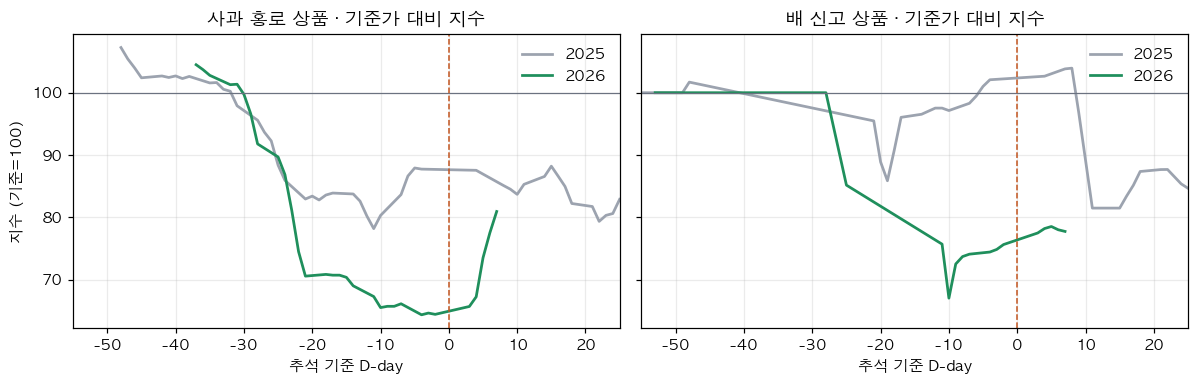

In [3]:
BASE = (-50, -29)

def indexed(d):
    key = ["year", "mrkt_cd", "item_nm", "vrty_nm", "grd_nm"]
    base = d[d.dday.between(*BASE)].groupby(key).price.mean().rename("base")
    out = d.join(base, on=key).dropna(subset=["base"])
    out["idx"] = out.price / out.base * 100
    return out

ix = indexed(df)
print("기준가가 있는 시장-품종-등급 조합:", ix.groupby(["year","mrkt_cd","vrty_nm","grd_nm"]).ngroups)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (item, vrty) in zip(axes, FOCUS):
    for y, c in [(2025, "#9CA3AF"), (2026, "#1F8F5C")]:
        s = ix[(ix.year == y) & (ix.item_nm == item) & (ix.vrty_nm == vrty) & (ix.grd_nm == "상품")]
        s = s.groupby("dday").idx.median().rolling(3, center=True, min_periods=1).mean()
        ax.plot(s.index, s.values, color=c, label=str(y), lw=1.8)
    ax.axhline(100, color="#6B7280", lw=.8); ax.axvline(0, color="#C2541F", ls="--", lw=1)
    ax.set_title(f"{item} {vrty} 상품 · 기준가 대비 지수"); ax.set_xlabel("추석 기준 D-day"); ax.legend(frameon=False)
    ax.set_xlim(-55, 25); ax.grid(alpha=.25)
axes[0].set_ylabel("지수 (기준=100)")
plt.tight_layout()

In [4]:
WINDOWS = {"추석 3~2주 전 (D-21~D-15)": (-21, -15), "추석 직전 2주 (D-14~D-1)": (-14, -1), "추석 후 1주 (D+1~D+7)": (1, 7)}

def window_table(d, by):
    rows = []
    for name, (a, b) in WINDOWS.items():
        g = d[d.dday.between(a, b)].groupby(by).idx.median().rename(name)
        rows.append(g)
    return pd.concat(rows, axis=1)

focus = ix[ix.grd_nm == "상품"]
window_table(focus[focus.vrty_nm.isin(["홍로", "신고"])], ["item_nm", "vrty_nm", "year"])

추석 3~2주 전 (D-21~D-15)  추석 직전 2주 (D-14~D-1)  \
item_nm vrty_nm year                                               
배       신고      2025                   96.0                 97.5   
사과      홍로      2025                   84.0                 84.2   
                2026                   70.5                 66.0   
배       신고      2026                    NaN                 74.0   

                      추석 후 1주 (D+1~D+7)  
item_nm vrty_nm year                     
배       신고      2025              102.7  
사과      홍로      2025               86.1  
                2026               74.9  
배       신고      2026               78.5

## 3. 상품과 중품, 명절에 격차가 벌어질까?

제수용·선물용으로 **좋은 등급**을 찾는 수요가 몰리면 상품-중품 가격 차이가 커질 것이다.
같은 날 같은 시장에서 상품과 중품이 둘 다 조사된 경우만 골라 **상품 ÷ 중품** 비율을 본다.

구간                    평소 (D-22 이전)  추석 직전 3주  추석 이후
item_nm vrty_nm year                               
배       신고      2025           1.2       1.2    1.2
                2026           1.4       1.2    1.2
사과      홍로      2025           1.3       1.2    1.3
                2026           1.2       1.2    1.3

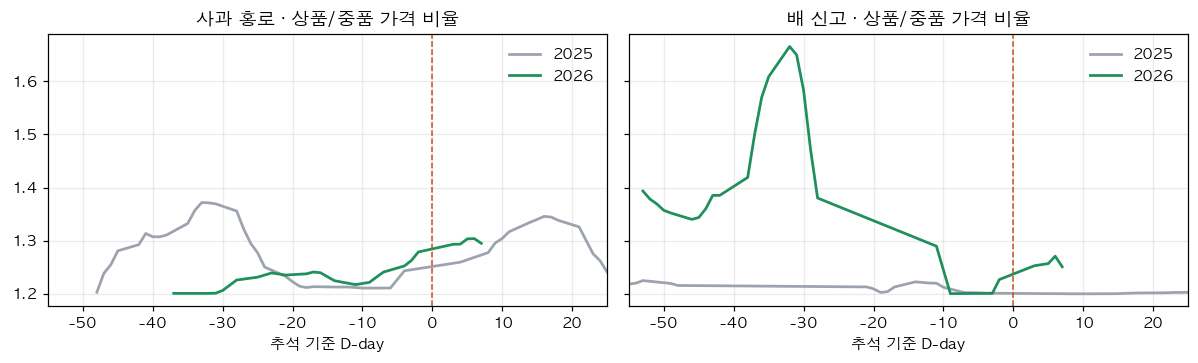

In [5]:
pair = (df[df.grd_nm.isin(["상품", "중품"])]
        .pivot_table(index=["year", "date", "dday", "mrkt_cd", "item_nm", "vrty_nm"], columns="grd_nm", values="price")
        .dropna().reset_index())
pair["ratio"] = pair["상품"] / pair["중품"]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.4), sharey=True)
for ax, (item, vrty) in zip(axes, FOCUS):
    for y, c in [(2025, "#9CA3AF"), (2026, "#1F8F5C")]:
        s = pair[(pair.year == y) & (pair.item_nm == item) & (pair.vrty_nm == vrty)]
        s = s.groupby("dday").ratio.median().rolling(5, center=True, min_periods=2).mean()
        ax.plot(s.index, s.values, color=c, label=str(y), lw=1.8)
    ax.axvline(0, color="#C2541F", ls="--", lw=1)
    ax.set_title(f"{item} {vrty} · 상품/중품 가격 비율"); ax.set_xlabel("추석 기준 D-day"); ax.legend(frameon=False)
    ax.set_xlim(-55, 25); ax.grid(alpha=.25)
plt.tight_layout()

g = pair[pair.vrty_nm.isin(["홍로", "신고"])].copy()
g["구간"] = pd.cut(g.dday, [-60, -22, -1, 30], labels=["평소 (D-22 이전)", "추석 직전 3주", "추석 이후"])
g.groupby(["item_nm", "vrty_nm", "year", "구간"], observed=True).ratio.median().unstack("구간")

## 4. 전통시장 vs 유통업체 — 어느 채널이 명절에 더 움직였나

추석 3~2주 전 (D-21~D-15)  추석 직전 2주 (D-14~D-1)  \
item_nm vrty_nm year channel                                               
배       신고      2025 유통업체                      97.5                102.0   
                     전통시장                      66.6                 80.0   
사과      홍로      2025 유통업체                      76.5                 74.9   
                     전통시장                      93.1                 94.4   
                2026 유통업체                      65.2                 62.6   
                     전통시장                      88.9                 84.2   
배       신고      2026 유통업체                       NaN                 61.3   
                     전통시장                       NaN                 81.3   

                              추석 후 1주 (D+1~D+7)  
item_nm vrty_nm year channel                     
배       신고      2025 유통업체                 123.1  
                     전통시장                  80.0  
사과      홍로      2025 유통업체                  81.9  
                     전통시장                  94.9  
                2026 유통업체                  74.2  
                     전통시장                  79.0  
배       신고      2026 유통업체                  59.9  
                     전통시장                  80.9

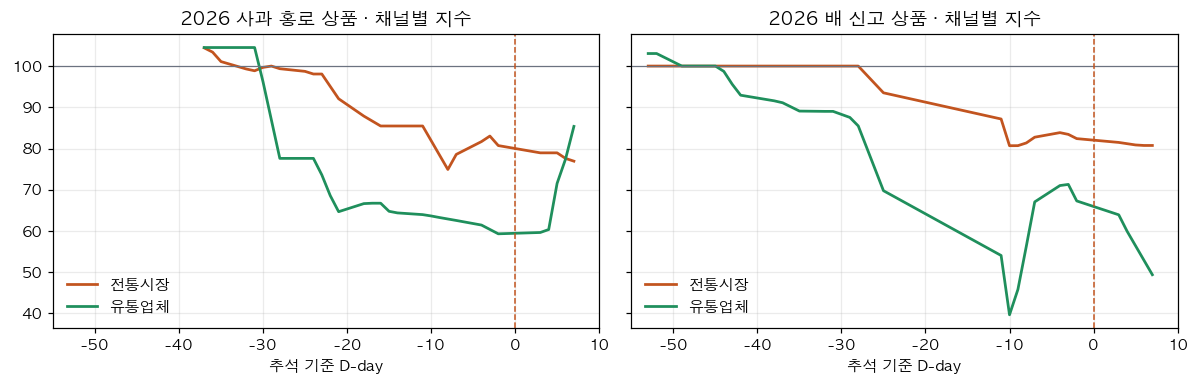

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), sharey=True)
for ax, (item, vrty) in zip(axes, FOCUS):
    for ch, c in [("전통시장", "#C2541F"), ("유통업체", "#1F8F5C")]:
        s = focus[(focus.year == 2026) & (focus.item_nm == item) & (focus.vrty_nm == vrty) & (focus.channel == ch)]
        s = s.groupby("dday").idx.median().rolling(3, center=True, min_periods=1).mean()
        ax.plot(s.index, s.values, color=c, label=ch, lw=1.8)
    ax.axhline(100, color="#6B7280", lw=.8); ax.axvline(0, color="#C2541F", ls="--", lw=1)
    ax.set_title(f"2026 {item} {vrty} 상품 · 채널별 지수"); ax.set_xlabel("추석 기준 D-day"); ax.legend(frameon=False)
    ax.set_xlim(-55, 10); ax.grid(alpha=.25)
plt.tight_layout()

window_table(focus[focus.vrty_nm.isin(["홍로", "신고"])], ["item_nm", "vrty_nm", "year", "channel"])

## 5. 현장 기록과 연결하기 — 9/23 이마트 신도림점

필드노트 카드에 적어둔 가격을 아래에 넣으면, 같은 날 전국 소매가격 분포 중 어디쯤인지 계산한다.
(먼슬리 리포트 → 내보내기 텍스트에서 가격 체크 카드를 옮겨 적으면 된다. 10개 기준으로 환산해서 넣기)

In [7]:
MY_OBS = [
    # ("사과", "홍로", "상품", 10개당 가격),  ← 예: ("사과", "홍로", "상품", 25900)
]
day = df[(df.date.between("2026-09-21", "2026-09-23"))]
for item, vrty, grd, p in MY_OBS:
    s = day[(day.item_nm == item) & (day.vrty_nm == vrty) & (day.grd_nm == grd)].price
    pct = (s < p).mean() * 100
    print(f"{item} {vrty} {grd} {p:,}원 → 같은 주 전국 {len(s)}건 중 상위 {100-pct:.0f}% (중앙값 {s.median():,.0f}원)")
if not MY_OBS:
    print("MY_OBS 에 현장 가격을 넣으면 비교 결과가 나와요.")

MY_OBS 에 현장 가격을 넣으면 비교 결과가 나와요.


## 6. 정리

**① "명절이라 비싸다"는 데이터로는 안 보인다.**
두 해 모두 추석 직전 지수가 100 아래였다. 2026년 홍로 상품은 기준가(8월 초중순 첫물) 대비 **약 66%**, 신고 상품은 **약 74%** 수준.
명절 수요보다 **햇과일 출하가 본격화되는 공급 효과**가 훨씬 컸다. 2025년(홍로 84, 신고 97.5)보다 2026년 하락 폭이 큰 건
추석이 11일 빨라 출하 피크와 더 정확히 겹쳤기 때문으로 추정된다.

**② 등급 프리미엄도 벌어지지 않았다.**
상품/중품 가격 비율은 1.2~1.3배로 명절 전후 거의 같았다. 2026 신고는 오히려 1.4 → 1.2로 좁아졌다.
"좋은 등급에 수요가 몰린다"면 상품만 따로 오를 텐데, 그런 흐름은 없었다.

**③ 가격을 크게 움직인 건 유통업체였다.** ← 가장 흥미로운 결과
2026 추석 직전 2주, 유통업체 지수는 홍로 **63** / 신고 **61**, 전통시장은 홍로 84 / 신고 81.
그리고 **추석이 지나자 유통업체 홍로 지수가 59 → 85로 바로 반등**했다.
→ 대형 유통사가 명절 집객용으로 **물량을 미리 확보해 행사가를 걸고**, 명절이 끝나면 정상가로 돌리는 패턴으로 해석된다.
9/23 이마트에서 본 제수용 과일 대량 진열·행사 POP와 일치하는 그림이다.

**MD 관점 시사점**
- 명절 과일은 "가격을 올리는 시즌"이 아니라 **"행사가로 고객을 끌어오는 시즌"**. 마진은 산지 물량 선확보(계약재배·사전 매입)에서 나온다.
- 추석이 빠른 해일수록 햇과일 공급과 겹쳐 원가 부담이 줄어든다 → 추석 시점에 따라 **행사 강도와 매입 시기를 다르게** 가져갈 수 있다.
- 명절 직후 유통업체 가격 반등 구간은 전통시장 대비 가격 경쟁력이 약해지는 시기라, **명절 후 잔여 물량 운영**이 따로 필요하다.

**한계**
- 기준가 기간(D-50~D-29)이 홍로 첫 출하 시기와 겹쳐 하락 폭이 실제보다 크게 보일 수 있다 (첫물 프리미엄 포함).
- 가격은 '10개당'이라 **과일 크기(제수용 대과 vs 일반)를 구분하지 못한다.** 제수용만의 가격은 따로 볼 수 없다.
- 조사처가 시장별 하루 1건이고 유통업체 이름이 익명이라, 특정 업체(이마트 등) 단위로는 볼 수 없다.
- 2026년은 10/2까지만 있어 추석 이후 흐름은 1주만 확인했다.

**다음에 해볼 것**: 가락시장 도매 경락가·반입량을 붙여 "도매가가 먼저 내렸는지(원가 하락) vs 소매만 내렸는지(행사)"를 구분하기.